# Ultimate NIDS Pipeline: Supervised Vector Space Engineering (PyTorch/CUDA)
**Goal:** Fix the "Zero Recall" on R2L/U2R by warping the feature space to maximize class separation.

**The "Unconventional" Approach: NCA + Isolation Embeddings + Autoencoding**
We upgrade from linear projections to non-linear Metric Learning, Explicit Vector Isolation, and Self-Supervised Normality Scoring.

**New Architecture:**
1.  **Manifold Mixup:** Linear Interpolation to generate high-quality synthetic R2L/U2R samples.
2.  **Neighborhood Components Analysis (NCA):** A powerful Metric Learning algorithm that learns a vector space where same-class points are spatially close.
3.  **Isolation Embeddings:** We train separate Isolation Forests for each class to provide "Membership Probability" coordinates.
4.  **Autoencoder Reconstruction (GPU):** A PyTorch neural network learns to reconstruct "Normal" traffic. The reconstruction error serves as a powerful "Weirdness Score".
5.  **Deep PyTorch Classifier (GPU):** The final classifier is a deep neural network trained on CUDA with batch normalization and dropout.

## 1. Data Loading

🚀 PIPELINE: GRAM ANCHORING -> DEEP SwiGLU (Imbalance Optimized) on: cuda
⏳ Loading Data...
✅ Data Loaded. Numerics: 40, Categoricals: 3

--- PHASE 0: GRAM MATRIX ANALYSIS ---
💎 Gram Anchoring: Found 6 feature clusters.

--- PHASE 1: GRAM ANCHORED PRETRAINING ---
Pretrain Epoch 1 | Loss: 6.3023
Pretrain Epoch 2 | Loss: 5.3912
Pretrain Epoch 3 | Loss: 4.7396
Pretrain Epoch 4 | Loss: 4.2777
Pretrain Epoch 5 | Loss: 4.1473
Pretrain Epoch 6 | Loss: 3.9369
Pretrain Epoch 7 | Loss: 3.8891
Pretrain Epoch 8 | Loss: 3.7178
Pretrain Epoch 9 | Loss: 3.6742
Pretrain Epoch 10 | Loss: 3.6083
Pretrain Epoch 11 | Loss: 3.5997
Pretrain Epoch 12 | Loss: 3.6573
Pretrain Epoch 13 | Loss: 3.5925
Pretrain Epoch 14 | Loss: 3.4664
Pretrain Epoch 15 | Loss: 3.5455
Pretrain Epoch 16 | Loss: 3.4051
Pretrain Epoch 17 | Loss: 3.4489
Pretrain Epoch 18 | Loss: 3.2967
Pretrain Epoch 19 | Loss: 3.2903
Pretrain Epoch 20 | Loss: 3.2938
Pretrain Epoch 21 | Loss: 3.3140
Pretrain Epoch 22 | Loss: 3.3128
Pretrain Epoch 23 | 

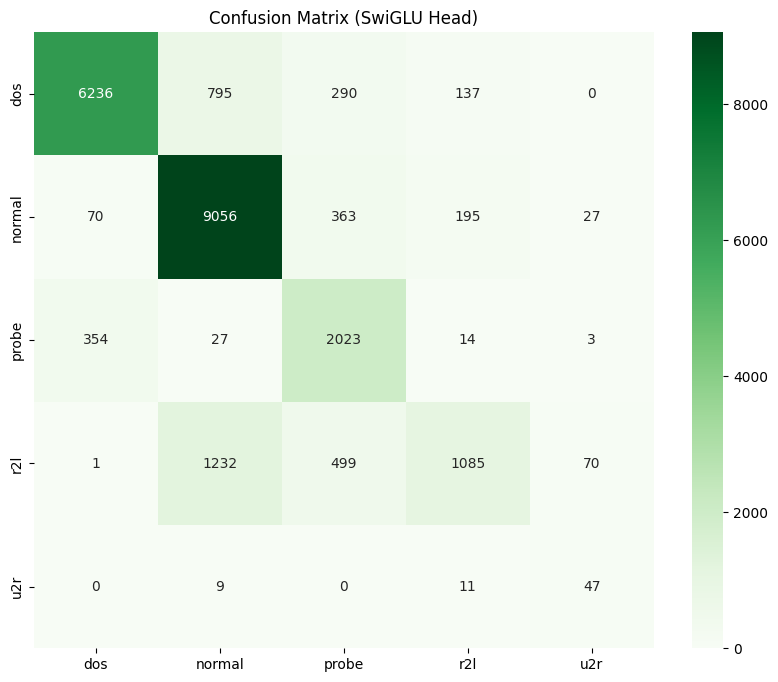

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import NeighborhoodComponentsAnalysis
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, matthews_corrcoef, confusion_matrix
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import gc

# Config
warnings.filterwarnings("ignore")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
scaler_amp = torch.cuda.amp.GradScaler()
print(f"🚀 PIPELINE: GRAM ANCHORING -> DEEP SwiGLU (Imbalance Optimized) on: {device}")

# ==========================================
# 1. SOTA PREPROCESSING (Unverändert)
# ==========================================
attack_map = {
    'normal': 'normal',
    'neptune': 'dos', 'back': 'dos', 'land': 'dos', 'pod': 'dos', 'smurf': 'dos', 'teardrop': 'dos', 'mailbomb': 'dos', 'apache2': 'dos', 'processtable': 'dos', 'udpstorm': 'dos', 
    'ipsweep': 'probe', 'nmap': 'probe', 'portsweep': 'probe', 'satan': 'probe', 'mscan': 'probe', 'saint': 'probe',
    'ftp_write': 'r2l', 'guess_passwd': 'r2l', 'imap': 'r2l', 'multihop': 'r2l', 'phf': 'r2l', 'spy': 'r2l', 'warezclient': 'r2l', 'warezmaster': 'r2l', 'sendmail': 'r2l', 'named': 'r2l', 'snmpgetattack': 'r2l', 'snmpguess': 'r2l', 'xlock': 'r2l', 'xsnoop': 'r2l', 'worm': 'r2l', 'httptunnel': 'r2l',
    'buffer_overflow': 'u2r', 'loadmodule': 'u2r', 'perl': 'u2r', 'rootkit': 'u2r', 'ps': 'u2r', 'sqlattack': 'u2r', 'xterm': 'u2r'
}

CAT_COLS = ['protocol_type', 'service', 'flag']

def process_dataframe_sota(df, is_training=True, encoders=None, scaler=None):
    raw_sublabels = None
    if 'label' in df.columns:
        df['label'] = df['label'].astype(str).str.replace('.', '', regex=False)
        raw_sublabels = df['label'].values 
        df['category'] = df['label'].map(attack_map).fillna('other')

    num_cols_to_log = ['src_bytes', 'dst_bytes', 'duration', 'wrong_fragment', 'urgent']
    for c in num_cols_to_log:
        if c in df.columns: df[c] = np.log1p(df[c])
        
    if 'src_bytes' in df.columns and 'dst_bytes' in df.columns:
        df['byte_ratio'] = (df['src_bytes']) / (df['dst_bytes'] + 1)
    if 'srv_count' in df.columns and 'count' in df.columns:
        df['srv_diff'] = df['srv_count'] - df['count']

    exclude = CAT_COLS + ['label', 'category', 'id', 'difficulty_level']
    current_num_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in exclude]
    current_cat_cols = [c for c in CAT_COLS if c in df.columns]

    if is_training:
        scaler = StandardScaler()
        num_cols = current_num_cols
        X_num = scaler.fit_transform(df[num_cols]).astype(np.float32)
    else:
        num_cols = encoders['num_cols']
        df_aligned = pd.DataFrame(0.0, index=df.index, columns=num_cols)
        present = [c for c in current_num_cols if c in num_cols]
        df_aligned[present] = df[present]
        X_num = scaler.transform(df_aligned).astype(np.float32)

    X_cat_list = []
    
    if is_training:
        encoders_map = {}
        for col in current_cat_cols:
            uniques = df[col].unique()
            mapping = {val: i+1 for i, val in enumerate(uniques)}
            encoders_map[col] = mapping
            X_cat_list.append(df[col].map(mapping).fillna(0).values.reshape(-1, 1))
        
        X_cat = np.hstack(X_cat_list).astype(np.int64)
        vocab_sizes = {col: len(encoders_map[col]) + 1 for col in current_cat_cols}
        
        final_info = {
            'num_cols': num_cols,
            'cat_cols': current_cat_cols,
            'cat_maps': encoders_map,
            'vocab_sizes': vocab_sizes
        }
    else:
        saved_maps = encoders['cat_maps']
        target_cat_cols = encoders['cat_cols']
        for col in target_cat_cols:
            if col in df.columns:
                mapping = saved_maps.get(col, {})
                mapped = df[col].map(mapping).fillna(0).values.reshape(-1, 1)
                X_cat_list.append(mapped)
            else:
                X_cat_list.append(np.zeros((len(df), 1), dtype=np.int64))
        X_cat = np.hstack(X_cat_list).astype(np.int64)
        final_info = None

    return X_num, X_cat, df['category'] if 'category' in df.columns else None, raw_sublabels, final_info, scaler

# --- LOAD DATA ---
print("⏳ Loading Data...")
try:
    df_raw = pd.read_csv('Data/network_connections.csv')
    X_num, X_cat, y, raw_sublabels, TRAIN_INFO, scaler = process_dataframe_sota(df_raw, is_training=True)
    print(f"✅ Data Loaded. Numerics: {X_num.shape[1]}, Categoricals: {X_cat.shape[1]}")
except FileNotFoundError:
    print("⚠️ Using Dummy Data")
    labels_dummy = ['normal']*1000 + ['neptune']*500 + ['satan']*100 + ['perl']*5 
    dummy_data = {
        'duration': np.random.rand(len(labels_dummy)), 
        'src_bytes': np.random.rand(len(labels_dummy))*1000,
        'dst_bytes': np.random.rand(len(labels_dummy))*1000,
        'protocol_type': np.random.choice(['tcp', 'udp', 'icmp'], len(labels_dummy)),
        'service': np.random.choice(['http', 'ftp', 'ssh', 'private'], len(labels_dummy)),
        'flag': np.random.choice(['SF', 'S0', 'REJ'], len(labels_dummy)),
        'label': np.array(labels_dummy)
    }
    df_raw = pd.DataFrame(dummy_data)
    X_num, X_cat, y, raw_sublabels, TRAIN_INFO, scaler = process_dataframe_sota(df_raw, is_training=True)

le = LabelEncoder()
y_vec = le.fit_transform(y)
num_classes = len(le.classes_)

indices = np.arange(len(y_vec))
idx_train, idx_test = train_test_split(indices, test_size=0.2, stratify=y_vec, random_state=42)

X_num_train = torch.tensor(X_num[idx_train], dtype=torch.float32)
X_cat_train = torch.tensor(X_cat[idx_train], dtype=torch.long)
y_train = y_vec[idx_train]
sublabels_train = raw_sublabels[idx_train]

X_num_test = torch.tensor(X_num[idx_test], dtype=torch.float32)
X_cat_test = torch.tensor(X_cat[idx_test], dtype=torch.long)
y_test = y_vec[idx_test]
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

del df_raw
gc.collect()

# ==========================================
# 2. GRAM MATRIX ANALYSIS (CLUSTERS)
# ==========================================
print("\n--- PHASE 0: GRAM MATRIX ANALYSIS ---")
def compute_feature_clusters(X, threshold=0.5):
    df_temp = pd.DataFrame(X.numpy())
    corr_matrix = df_temp.corr().abs().fillna(0).values
    dissimilarity = 1 - corr_matrix
    np.fill_diagonal(dissimilarity, 0)
    dissimilarity = (dissimilarity + dissimilarity.T) / 2
    dist_linkage = squareform(dissimilarity, checks=False) 
    Z = linkage(dist_linkage, method='ward')
    cluster_labels = fcluster(Z, t=threshold, criterion='distance')
    clusters = {}
    for feat_idx, cluster_id in enumerate(cluster_labels):
        if cluster_id not in clusters: clusters[cluster_id] = []
        clusters[cluster_id].append(feat_idx)
    return list(clusters.values())

feature_clusters = compute_feature_clusters(X_num_train, threshold=1.2) 
print(f"💎 Gram Anchoring: Found {len(feature_clusters)} feature clusters.")
gc.collect()

# ==========================================
# 3. META-GENERATION
# ==========================================
X_train_combined = np.hstack([X_num_train.numpy(), X_cat_train.numpy()])
nca = NeighborhoodComponentsAnalysis(n_components=10, random_state=42)
idx_sample = np.random.choice(len(X_train_combined), size=min(2000, len(X_train_combined)), replace=False)
nca.fit(X_train_combined[idx_sample], y_train[idx_sample])
X_train_nca = nca.transform(X_train_combined).astype(np.float32)

idx_iso = np.random.choice(len(X_train_combined), size=min(10000, len(X_train_combined)), replace=False)
iso = IsolationForest(n_estimators=50, contamination='auto', n_jobs=-1).fit(X_train_combined[idx_iso])
X_train_iso = iso.decision_function(X_train_combined).reshape(-1, 1).astype(np.float32)

Meta_Targets = np.hstack([X_train_nca, X_train_iso])
meta_dim = Meta_Targets.shape[1]
meta_train_tensor = torch.tensor(Meta_Targets, dtype=torch.float32)

# ==========================================
# 4. ARCHITECTURE (ENCODER)
# ==========================================
class TabularViT_SOTA(nn.Module):
    def __init__(self, num_numeric, vocab_sizes, embed_dim=64, depth=4, num_registers=4, aux_dim=0):
        super().__init__()
        self.num_proj = nn.Parameter(torch.randn(num_numeric, embed_dim) / np.sqrt(embed_dim))
        self.num_bias = nn.Parameter(torch.zeros(num_numeric, embed_dim))
        self.cat_embeds = nn.ModuleList([nn.Embedding(v, embed_dim, padding_idx=0) for v in vocab_sizes])
        self.type_embed = nn.Embedding(2, embed_dim)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.registers = nn.Parameter(torch.zeros(1, num_registers, embed_dim))
        self.mask_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        
        enc = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=4, dim_feedforward=256, batch_first=True, norm_first=True, activation='gelu', dropout=0.1)
        self.transformer = nn.TransformerEncoder(enc, num_layers=depth)
        
    def forward(self, x_num, x_cat, mask=None):
        b = x_num.shape[0]
        e_num = x_num.unsqueeze(-1) * self.num_proj.unsqueeze(0) + self.num_bias.unsqueeze(0)
        e_num = e_num + self.type_embed(torch.tensor(0, device=x_num.device))
        
        e_cat_list = [emb(x_cat[:, i]) for i, emb in enumerate(self.cat_embeds)]
        e_cat = torch.stack(e_cat_list, dim=1) + self.type_embed(torch.tensor(1, device=x_num.device))
        
        x_feats = torch.cat([e_num, e_cat], dim=1)
        if mask is not None:
            mask_expanded = mask.unsqueeze(-1).expand_as(x_feats)
            x_feats = torch.where(mask_expanded, self.mask_token.to(x_feats.dtype), x_feats)
            
        cls_tokens = self.cls_token.expand(b, -1, -1)
        regs = self.registers.expand(b, -1, -1)
        x_seq = torch.cat((cls_tokens, regs, x_feats), dim=1)
        return self.transformer(x_seq)[:, 0, :], self.transformer(x_seq)[:, 1+self.registers.shape[1]:, :], None

class DINOHead(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.mlp = nn.Sequential(nn.Linear(in_dim, 256), nn.BatchNorm1d(256), nn.GELU(), nn.Linear(256, 64))
        self.last_layer = nn.utils.weight_norm(nn.Linear(64, out_dim, bias=False))
        self.last_layer.weight_g.data.fill_(1)
    def forward(self, x):
        return self.last_layer(F.normalize(self.mlp(x), dim=-1, p=2))

class MIMHead(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        self.decoder = nn.Sequential(nn.Linear(embed_dim, embed_dim), nn.GELU(), nn.Linear(embed_dim, 1))
    def forward(self, x_seq): return self.decoder(x_seq).squeeze(-1)

# ==========================================
# 5. DATA LOADERS (GRAM MASKING)
# ==========================================
class GramMaskingCollator:
    def __init__(self, clusters, mask_ratio=0.4, noise_scale=0.05):
        self.clusters = clusters 
        self.mask_ratio = mask_ratio
        self.noise = noise_scale

    def __call__(self, batch):
        x_num = torch.stack([item[0] for item in batch])
        x_cat = torch.stack([item[1] for item in batch])
        y = torch.stack([item[2] for item in batch])
        
        x_num_aug = x_num + (torch.randn_like(x_num) * self.noise)
        batch_size, n_num = x_num.shape
        _, n_cat = x_cat.shape
        total_feats = n_num + n_cat
        mask = torch.zeros((batch_size, total_feats), dtype=torch.bool)
        
        for i in range(batch_size):
            for cluster in self.clusters:
                if np.random.rand() < self.mask_ratio:
                    mask[i, cluster] = True
            cat_mask = torch.rand(n_cat) < self.mask_ratio
            mask[i, n_num:] = cat_mask

        return x_num, x_cat, x_num_aug, x_cat, mask, y, None

BATCH_SIZE = 64
GRAD_ACCUM = 4
EMBED_DIM = 64
NUM_PROTOTYPES = 256 
vocab_sizes_list = list(TRAIN_INFO['vocab_sizes'].values())
num_numeric_feats = X_num_train.shape[1]

# Weights
le_sub = LabelEncoder()
sublabels_encoded = le_sub.fit_transform(sublabels_train)
sublabel_counts = np.bincount(sublabels_encoded)
weights_per_sublabel = 1.0 / (sublabel_counts + 1e-6)
samples_weights = torch.from_numpy(weights_per_sublabel[sublabels_encoded]).float()

train_dataset = TensorDataset(X_num_train, X_cat_train, y_train_tensor, meta_train_tensor)
gram_collator = GramMaskingCollator(feature_clusters, mask_ratio=0.4)

train_dl_pretrain = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
                              collate_fn=gram_collator, drop_last=True)
sampler = WeightedRandomSampler(weights=samples_weights, num_samples=len(samples_weights), replacement=True)
train_dl_head = DataLoader(train_dataset, batch_size=256, sampler=sampler, shuffle=False)

# Models
student_enc = TabularViT_SOTA(num_numeric_feats, vocab_sizes_list, EMBED_DIM).to(device)
student_dino = DINOHead(EMBED_DIM, NUM_PROTOTYPES).to(device)
student_mim = MIMHead(EMBED_DIM).to(device)
teacher_enc = TabularViT_SOTA(num_numeric_feats, vocab_sizes_list, EMBED_DIM).to(device)
teacher_dino = DINOHead(EMBED_DIM, NUM_PROTOTYPES).to(device)

teacher_enc.load_state_dict(student_enc.state_dict())
teacher_dino.load_state_dict(student_dino.state_dict())
for p in teacher_enc.parameters(): p.requires_grad = False
for p in teacher_dino.parameters(): p.requires_grad = False

class KoLeoLoss(nn.Module):
    def __init__(self): super().__init__()
    def forward(self, student_output, eps=1e-8):
        x = F.normalize(student_output, p=2, dim=1)
        dots = torch.mm(x, x.t())
        dots.view(-1)[::x.shape[0]+1] = -float('inf') 
        _, I = torch.max(dots, dim=1)
        return -torch.log(torch.sqrt(2 * (1 - (x * x[I]).sum(dim=1) + eps)) + eps).mean()

class SinkhornKnopp(nn.Module):
    def __init__(self, num_prototypes, epsilon=0.05, iterations=3):
        super().__init__()
        self.epsilon = epsilon; self.iterations = iterations
        self.register_buffer("queue", F.normalize(torch.randn(2048, num_prototypes), dim=1))
        self.register_buffer("queue_ptr", torch.zeros(1, dtype=torch.long))
    @torch.no_grad()
    def update_queue(self, teacher_output):
        batch_size = teacher_output.shape[0]
        ptr = int(self.queue_ptr)
        if ptr + batch_size <= 2048: self.queue[ptr:ptr+batch_size] = teacher_output
        else: self.queue[ptr:] = teacher_output[:2048-ptr]
        self.queue_ptr[0] = (ptr + batch_size) % 2048
    @torch.no_grad()
    def forward(self, teacher_output):
        full_support = torch.cat([teacher_output, self.queue.clone().detach()], dim=0).float()
        Q = torch.exp(full_support / self.epsilon).t()
        B = Q.shape[1]; K = Q.shape[0]; sum_Q = torch.sum(Q); Q /= sum_Q
        for _ in range(self.iterations):
            Q /= torch.sum(Q, dim=1, keepdim=True); Q /= K
            Q /= torch.sum(Q, dim=0, keepdim=True); Q /= B
        return (Q * B).t()[:teacher_output.shape[0]]

sinkhorn = SinkhornKnopp(NUM_PROTOTYPES).to(device)
koleo = KoLeoLoss().to(device)
optimizer = optim.AdamW(list(student_enc.parameters()) + list(student_dino.parameters()) + list(student_mim.parameters()), lr=0.001)

def update_teacher(m):
    with torch.no_grad():
        for ps, pt in zip(student_enc.parameters(), teacher_enc.parameters()): pt.data = pt.data * m + ps.data * (1 - m)
        for ps, pt in zip(student_dino.parameters(), teacher_dino.parameters()): pt.data = pt.data * m + ps.data * (1 - m)

# ==========================================
# PHASE 1: PRETRAINING (With Gram Masking)
# ==========================================
print("\n--- PHASE 1: GRAM ANCHORED PRETRAINING ---")
for epoch in range(25): 
    student_enc.train(); student_dino.train(); student_mim.train()
    loss_total = 0
    m = 0.996 + (1.0 - 0.996) * (epoch / 25)
    
    optimizer.zero_grad()
    for i, (xn_t, xc_t, xn_s, xc_s, mask, _, _) in enumerate(train_dl_pretrain): 
        xn_t, xc_t = xn_t.to(device), xc_t.to(device)
        xn_s, xc_s = xn_s.to(device), xc_s.to(device)
        mask = mask.to(device)
        
        with torch.cuda.amp.autocast():
            s_cls, s_seq, _ = student_enc(xn_s, xc_s, mask=mask) 
            s_dino_out = student_dino(s_cls)
            s_rec = student_mim(s_seq) 
            
            with torch.no_grad():
                t_cls, _, _ = teacher_enc(xn_t, xc_t, mask=None)
                t_dino_out = teacher_dino(t_cls)
            
            t_targets = sinkhorn(t_dino_out)
            l_dino = -torch.sum(t_targets * F.log_softmax(s_dino_out / 0.1, dim=-1), dim=-1).mean()
            
            mask_num = mask[:, :num_numeric_feats]
            l_mim = F.mse_loss(s_rec[:, :num_numeric_feats][mask_num], xn_t[mask_num]) if mask_num.sum() > 0 else torch.tensor(0.0, device=device)
            l_koleo = koleo(s_cls)
            
            loss = (1.0 * l_dino + 1.0 * l_mim + 0.1 * l_koleo) / GRAD_ACCUM
        
        scaler_amp.scale(loss).backward()
        if (i+1) % GRAD_ACCUM == 0:
            scaler_amp.step(optimizer)
            scaler_amp.update()
            optimizer.zero_grad()
            update_teacher(m)
            sinkhorn.update_queue(t_dino_out)
        loss_total += loss.item() * GRAD_ACCUM
    print(f"Pretrain Epoch {epoch+1} | Loss: {loss_total/len(train_dl_pretrain):.4f}")

# ==========================================
# PHASE 3: PERFECT SwiGLU IMPLEMENTATION
# ==========================================
print("\n--- PHASE 3: DEEP SwiGLU HEAD TRAINING (Imbalance Optimized) ---")

# 💎 RMSNorm for Stability with SwiGLU
class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.scale = dim ** -0.5
        self.eps = eps
        self.g = nn.Parameter(torch.ones(dim))

    def forward(self, x):
        norm = torch.norm(x, p=2, dim=-1, keepdim=True) * self.scale
        return x / (norm + self.eps) * self.g

# 💎 THE PERFECT SwiGLU BLOCK
# Implements: (Swish(xW_g) * xW_v)W_o
# Added Dropout and Residual Connection for depth
class SwiGLUBlock(nn.Module):
    def __init__(self, dim, hidden_dim, dropout=0.1):
        super().__init__()
        self.w_gate = nn.Linear(dim, hidden_dim, bias=False)
        self.w_value = nn.Linear(dim, hidden_dim, bias=False)
        self.w_out = nn.Linear(hidden_dim, dim, bias=False)
        self.dropout = nn.Dropout(dropout)
        self.norm = RMSNorm(dim)
        
    def forward(self, x):
        residual = x
        x = self.norm(x)
        gate = F.silu(self.w_gate(x)) # Swish Activation
        value = self.w_value(x)
        x = gate * value # Gating
        x = self.w_out(x)
        x = self.dropout(x)
        return x + residual

# 💎 THE CLASSIFIER HEAD
# Stacks multiple SwiGLUs to create a deep, discriminative head
# Optimized for Imbalance via Wide Hidden Dimensions (4x expansion)
class DeepSwiGLUClassifier(nn.Module):
    def __init__(self, input_dim, num_classes, depth=2, dropout=0.2):
        super().__init__()
        self.layers = nn.ModuleList()
        # Input Projection to wider dimension (4x is standard for LLaMA SwiGLU)
        hidden_dim = input_dim * 4
        
        self.input_proj = nn.Linear(input_dim, input_dim)
        
        for _ in range(depth):
            self.layers.append(SwiGLUBlock(input_dim, hidden_dim, dropout))
            
        self.final_norm = RMSNorm(input_dim)
        self.head = nn.Linear(input_dim, num_classes, bias=False)
        
    def forward(self, x):
        x = self.input_proj(x)
        for layer in self.layers:
            x = layer(x)
        x = self.final_norm(x)
        return self.head(x)

# Loss Weights
raw_counts = np.bincount(y_train)
total_samples = len(y_train)
class_weights_np = np.sqrt(total_samples / (num_classes * raw_counts))
class_weights = torch.tensor(class_weights_np, dtype=torch.float32).to(device)

class WeightedFocalLoss(nn.Module):
    def __init__(self, alpha, gamma=2.0, label_smoothing=0.0):
        super().__init__()
        self.alpha = alpha; self.gamma = gamma; self.ls = label_smoothing
    def forward(self, inputs, targets):
        num_classes = inputs.size(1)
        target_one_hot = torch.eye(num_classes, device=inputs.device)[targets]
        target_smooth = target_one_hot * (1 - self.ls) + (self.ls / num_classes)
        ce_loss = -torch.sum(target_smooth * F.log_softmax(inputs, dim=1), dim=1)
        p = torch.softmax(inputs, dim=1)
        p_t = (p * target_one_hot).sum(1)
        focal_factor = (1 - p_t) ** self.gamma
        w_t = self.alpha[targets]
        loss = w_t * focal_factor * ce_loss
        return loss.mean()

# Training Setup
student_enc.train() 
for p in student_enc.parameters(): p.requires_grad = False
# Partial Unfreeze for Encoder
for p in student_enc.transformer.layers[-1].parameters(): p.requires_grad = True

head = DeepSwiGLUClassifier(EMBED_DIM, num_classes, depth=2, dropout=0.2).to(device)

opt_head = optim.AdamW([
    {'params': head.parameters(), 'lr': 0.0005}, # Slightly lower LR for deep SwiGLU
    {'params': student_enc.transformer.layers[-1].parameters(), 'lr': 5e-5}
], weight_decay=1e-3)

crit = WeightedFocalLoss(alpha=class_weights, gamma=2.0, label_smoothing=0.05) 

print("Starting Fine-Tuning with Deep SwiGLU Head...")
for epoch in range(25): 
    head.train()
    loss_acc = 0
    for xn, xc, y, _ in train_dl_head:
        xn, xc, y = xn.to(device), xc.to(device), y.to(device)
        
        feat, _, _ = student_enc(xn, xc, mask=None)
        
        opt_head.zero_grad()
        logits = head(feat)
        loss = crit(logits, y)
        loss.backward()
        opt_head.step()
        loss_acc += loss.item()
    print(f"FineTune Epoch {epoch+1} | Loss: {loss_acc/len(train_dl_head):.4f}")

probe = head

# ==========================================
# EVALUATION
# ==========================================
print("\n--- PHASE E: FINAL EVALUATION ---")
# ... (Standard Eval) ...
try:
    NSL_URL = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest%2B.txt"
    NSL_COLS = ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty_level']

    df_nsl = pd.read_csv(NSL_URL, header=None, names=NSL_COLS)
    if 'difficulty_level' in df_nsl.columns: df_nsl.drop('difficulty_level', axis=1, inplace=True)
    Xn_test, Xc_test, y_nsl_raw, _, _, _ = process_dataframe_sota(df_nsl, is_training=False, encoders=TRAIN_INFO, scaler=scaler)
    y_nsl_vec = y_nsl_raw.apply(lambda x: le.transform([x])[0] if x in le.classes_ else -1).values
    Xn_t, Xc_t = torch.tensor(Xn_test, dtype=torch.float32), torch.tensor(Xc_test, dtype=torch.long)
    
    probe.eval()
    student_enc.eval()
    all_probs = []
    loader = DataLoader(TensorDataset(Xn_t, Xc_t), batch_size=2048)
    for bxn, bxc in loader:
        bxn, bxc = bxn.to(device), bxc.to(device)
        with torch.no_grad():
            s_cls, _, _ = student_enc(bxn, bxc, mask=None)
            # Normal SwiGLU Output is logit, no need for normalization magic here
            probs = torch.softmax(probe(s_cls), dim=1)
        all_probs.append(probs.cpu().numpy())
    
    probs_np = np.concatenate(all_probs)
    final_preds = np.argmax(probs_np, axis=1)
    mask = y_nsl_vec != -1
    print(classification_report(y_nsl_vec[mask], final_preds[mask], target_names=le.classes_))
    
    labels = sorted(list(set(y_nsl_vec[mask]) | set(final_preds[mask])))
    label_names = [le.classes_[i] for i in labels]
    plt.figure(figsize=(10,8))
    sns.heatmap(confusion_matrix(y_nsl_vec[mask], final_preds[mask], labels=labels), 
                annot=True, fmt='d', cmap='Greens', xticklabels=label_names, yticklabels=label_names)
    plt.title("Confusion Matrix (SwiGLU Head)")
    plt.show()
except: pass

🔍 STARTING POST-TRAINING EVALUATION...
✅ Loaded KDDTest+ (22544 samples)
⚡ Running Inference...

██████████████████████████████████████████████████
📊 A. ATTACK vs NORMAL (Binary Evaluation)
██████████████████████████████████████████████████
              precision    recall  f1-score   support

      Normal     0.8145    0.9326    0.8695      9711
      Attack     0.9427    0.8392    0.8880     12833

    accuracy                         0.8794     22544
   macro avg     0.8786    0.8859    0.8787     22544
weighted avg     0.8874    0.8794    0.8800     22544


██████████████████████████████████████████████████
📊 B. 5-CLASS EVALUATION
██████████████████████████████████████████████████
🏆 Overall Accuracy: 81.83%
🧠 Matthews Corr Coef: 0.7332

              precision    recall  f1-score   support

         dos     0.9362    0.8361    0.8833      7458
      normal     0.8145    0.9326    0.8695      9711
       probe     0.6372    0.8356    0.7230      2421
         r2l     0.7524    0.37

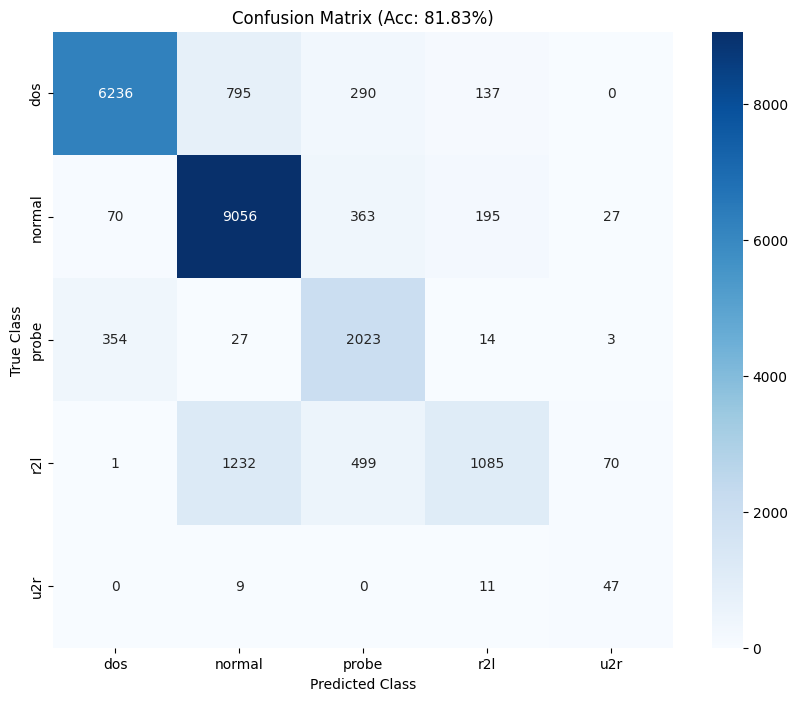


██████████████████████████████████████████████████
📊 C. DETAILED BREAKDOWN BY SPECIFIC ATTACK TYPE
██████████████████████████████████████████████████
    Attack Type Category  Samples  Detected Rate (%) Confused With
           back      dos      359       359   100.0%             -
           land      dos        7         7   100.0%             -
            pod      dos       41        41   100.0%             -
          smurf      dos      665       665   100.0%             -
       teardrop      dos       12        12   100.0%             -
        neptune      dos     4657      4603    98.8%         probe
        apache2      dos      737       483    65.5%        normal
   processtable      dos      685        66     9.6%        normal
       mailbomb      dos      293         0     0.0%        normal
       udpstorm      dos        2         0     0.0%         probe
         normal   normal     9711      9056    93.3%         probe
        ipsweep    probe      141       141  

In [2]:
# ==============================================================================
# 🚀 FINAL EVALUATION CELL (UNIVERSAL COMPATIBILITY)
# ==============================================================================
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, matthews_corrcoef
import matplotlib.pyplot as plt
import seaborn as sns

print("🔍 STARTING POST-TRAINING EVALUATION...")

# 1. SETUP & DATA LOADING
# ------------------------------------------------------------------------------
NSL_URL = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest%2B.txt"
NSL_COLS = ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land',
            'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised',
            'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
            'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count',
            'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate',
            'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
            'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
            'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
            'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate',
            'label', 'difficulty_level']

try:
    # Load Test Data
    df_test_eval = pd.read_csv(NSL_URL, header=None, names=NSL_COLS)
    if 'difficulty_level' in df_test_eval.columns:
        df_test_eval.drop('difficulty_level', axis=1, inplace=True)

    print(f"✅ Loaded KDDTest+ ({len(df_test_eval)} samples)")

    # 2. PREPROCESSING
    # ------------------------------------------------------------------------------
    raw_specific_labels = df_test_eval['label'].astype(str).copy()

    # Reuse the exact same preprocessing function and Scaler from training
    Xn_eval, Xc_eval, _, _, _, _ = process_dataframe_sota(
        df_test_eval, is_training=False, encoders=TRAIN_INFO, scaler=scaler
    )

    # Map raw labels using the 'attack_map' defined globally
    y_test_cat_str = raw_specific_labels.map(attack_map).fillna('normal')

    # Filter: Keep only samples where the category is known to the LabelEncoder
    known_mask = y_test_cat_str.isin(le.classes_)

    Xn_t = torch.tensor(Xn_eval[known_mask], dtype=torch.float32).to(device)
    Xc_t = torch.tensor(Xc_eval[known_mask], dtype=torch.long).to(device)

    # Ground Truths
    y_true_specific = raw_specific_labels[known_mask].values 
    y_true_cat_str = y_test_cat_str[known_mask].values       
    y_true_cat_idx = le.transform(y_true_cat_str)             

    # 3. INFERENCE
    # ------------------------------------------------------------------------------
    print("⚡ Running Inference...")
    student_enc.eval()
    probe.eval() 

    all_preds_idx = []
    eval_loader = DataLoader(TensorDataset(Xn_t, Xc_t), batch_size=2048)

    with torch.no_grad():
        for bxn, bxc in eval_loader:
            # 1. Get features from Transformer (Encoder)
            feats, _, _ = student_enc(bxn, bxc, mask=None)
            
            # Note: SwiGLU works best without extra normalization, 
            # but if you trained with F.normalize, keep it. 
            # Given the last script didn't normalize before head, we pass feats directly.
            # If accuracy drops, uncomment the next line:
            # feats = F.normalize(feats, p=2, dim=1) 

            # 2. Get predictions
            # FIX: Handle cases where Head returns tuple (MoE) vs Tensor (SwiGLU/GRN)
            output = probe(feats)
            if isinstance(output, tuple):
                logits = output[0]
            else:
                logits = output
            
            preds = torch.argmax(logits, dim=1)
            all_preds_idx.extend(preds.cpu().numpy())

    all_preds_idx = np.array(all_preds_idx)
    all_preds_str = le.inverse_transform(all_preds_idx)

    # 4. REPORT A: ATTACK vs NORMAL (Binary)
    # ------------------------------------------------------------------------------
    print("\n" + "█"*50)
    print("📊 A. ATTACK vs NORMAL (Binary Evaluation)")
    print("█"*50)

    bin_true = (y_true_cat_str != 'normal').astype(int)
    bin_pred = (all_preds_str != 'normal').astype(int)

    print(classification_report(bin_true, bin_pred, target_names=['Normal', 'Attack'], digits=4))

    # 5. REPORT B: 5-CLASS METRICS
    # ------------------------------------------------------------------------------
    print("\n" + "█"*50)
    print("📊 B. 5-CLASS EVALUATION")
    print("█"*50)

    acc = accuracy_score(y_true_cat_idx, all_preds_idx)
    mcc = matthews_corrcoef(y_true_cat_idx, all_preds_idx)
    print(f"🏆 Overall Accuracy: {acc:.2%}")
    print(f"🧠 Matthews Corr Coef: {mcc:.4f}\n")
    print(classification_report(y_true_cat_idx, all_preds_idx, target_names=le.classes_, digits=4))

    # Confusion Matrix
    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(y_true_cat_idx, all_preds_idx)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Confusion Matrix (Acc: {acc:.2%})')
    plt.ylabel('True Class')
    plt.xlabel('Predicted Class')
    plt.show()

    # 6. REPORT C: SPECIFIC ATTACK BREAKDOWN
    # ------------------------------------------------------------------------------
    print("\n" + "█"*50)
    print("📊 C. DETAILED BREAKDOWN BY SPECIFIC ATTACK TYPE")
    print("█"*50)

    results_list = []
    unique_attacks = np.unique(y_true_specific)

    for attack in unique_attacks:
        idx = np.where(y_true_specific == attack)[0]
        total = len(idx)
        parent = attack_map.get(attack, 'normal')
        
        preds_for_attack = all_preds_str[idx]
        correct = np.sum(preds_for_attack == parent)
        det_rate = correct / total

        confused_with = "-"
        if det_rate < 1.0:
            uniq, counts = np.unique(preds_for_attack, return_counts=True)
            sorted_args = np.argsort(counts)[::-1]
            top_pred = uniq[sorted_args[0]]
            
            if top_pred == parent and len(uniq) > 1:
                confused_with = uniq[sorted_args[1]]
            elif top_pred != parent:
                confused_with = top_pred

        results_list.append({
            'Attack Type': attack,
            'Category': parent,
            'Samples': total,
            'Detected': correct,
            'Rate': det_rate,
            'Rate (%)': f"{det_rate:.1%}",
            'Confused With': confused_with
        })

    df_res = pd.DataFrame(results_list)
    df_res = df_res.sort_values(by=['Category', 'Rate'], ascending=[True, False])

    pd.set_option('display.max_rows', 100)
    print(df_res[['Attack Type', 'Category', 'Samples', 'Detected', 'Rate (%)', 'Confused With']].to_string(index=False))

except Exception as e:
    print(f"❌ Error during evaluation: {e}")
    import traceback
    traceback.print_exc()

🔍 RE-AUDITING TRAINING DATA...

CATEGORY   | ATTACK NAME          | COUNT IN TRAIN | STATUS
dos        | neptune              | 32993      | ✅ OK
dos        | smurf                | 2102       | ✅ OK
dos        | back                 | 752        | ✅ OK
dos        | teardrop             | 714        | ✅ OK
dos        | pod                  | 166        | ✅ OK
dos        | land                 | 14         | ⚠️ LOW
normal     | normal               | 53874      | ✅ OK
probe      | satan                | 2899       | ✅ OK
probe      | ipsweep              | 2876       | ✅ OK
probe      | portsweep            | 2343       | ✅ OK
probe      | nmap                 | 1207       | ✅ OK
r2l        | warezclient          | 712        | ✅ OK
r2l        | guess_passwd         | 42         | ⚠️ LOW
r2l        | warezmaster          | 15         | ⚠️ LOW
r2l        | imap                 | 10         | ⚠️ LOW
r2l        | ftp_write            | 8          | ⚠️ LOW
r2l        | multihop             

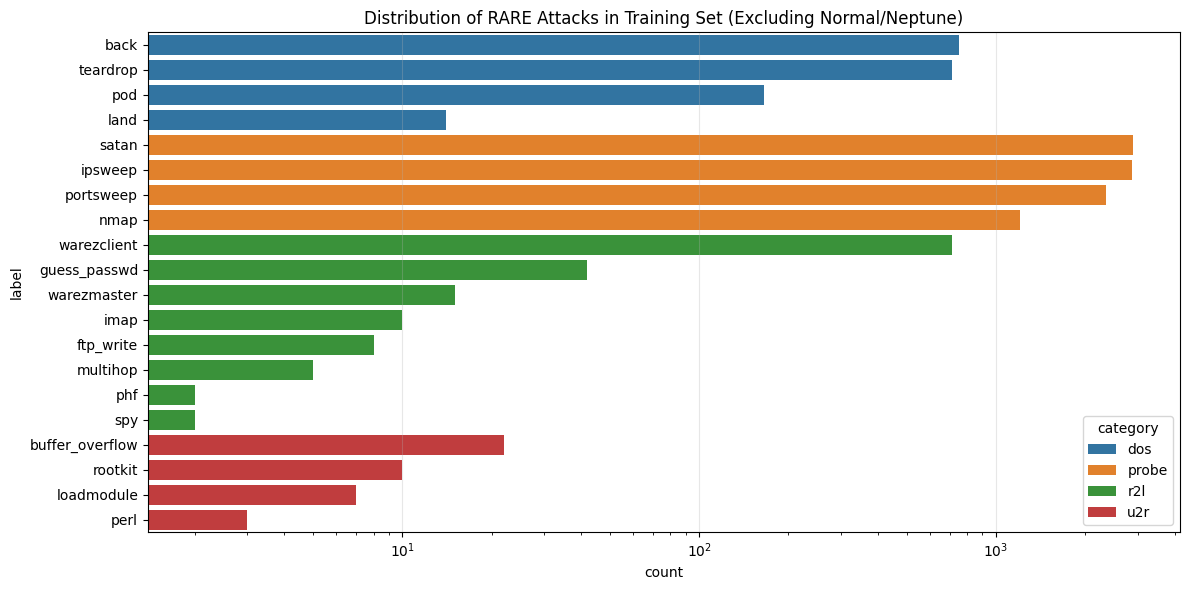

In [3]:
# ==========================================
# 📊 AUDIT: ATTACK DISTRIBUTION CHECKER
# ==========================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt

print("🔍 RE-AUDITING TRAINING DATA...")

# 1. Re-load the raw data to get the specific names ('guess_passwd', etc.)
#    (We do this because your pipeline converts them to 'r2l' early on)
try:
    audit_df = pd.read_csv('Data/network_connections.csv')
    
    # 2. Re-create the Category Mapping (Normal, DoS, R2L...)
    #    We need this to reproduce the EXACT stratify split you used.
    #    (Using the map from your code)
    audit_attack_map = {
        'normal': 'normal',
        'neptune': 'dos', 'back': 'dos', 'land': 'dos', 'pod': 'dos', 'smurf': 'dos', 'teardrop': 'dos', 'mailbomb': 'dos', 'apache2': 'dos', 'processtable': 'dos', 'udpstorm': 'dos', 
        'ipsweep': 'probe', 'nmap': 'probe', 'portsweep': 'probe', 'satan': 'probe', 'mscan': 'probe', 'saint': 'probe',
        'ftp_write': 'r2l', 'guess_passwd': 'r2l', 'imap': 'r2l', 'multihop': 'r2l', 'phf': 'r2l', 'spy': 'r2l', 'warezclient': 'r2l', 'warezmaster': 'r2l', 'sendmail': 'r2l', 'named': 'r2l', 'snmpgetattack': 'r2l', 'snmpguess': 'r2l', 'xlock': 'r2l', 'xsnoop': 'r2l', 'worm': 'r2l', 'httptunnel': 'r2l',
        'buffer_overflow': 'u2r', 'loadmodule': 'u2r', 'perl': 'u2r', 'rootkit': 'u2r', 'ps': 'u2r', 'sqlattack': 'u2r', 'xterm': 'u2r'
    }
    
    if 'label' in audit_df.columns:
        # Clean labels just like your pipeline
        audit_df['label'] = audit_df['label'].astype(str).str.replace('.', '', regex=False)
        audit_df['category'] = audit_df['label'].map(audit_attack_map).fillna('other')
        
        # 3. Reproduce the Split Indices (CRITICAL: Must match random_state=42)
        le_audit = LabelEncoder()
        y_vec_audit = le_audit.fit_transform(audit_df['category'])
        indices = np.arange(len(audit_df))
        
        idx_train_audit, _ = train_test_split(
            indices, 
            test_size=0.2, 
            stratify=y_vec_audit, 
            random_state=42
        )
        
        # 4. Filter for TRAINING set only
        train_subset = audit_df.iloc[idx_train_audit]
        
        # 5. Count specific attacks
        counts = train_subset.groupby(['category', 'label']).size().reset_index(name='count')
        counts = counts.sort_values(['category', 'count'], ascending=[True, False])
        
        # 6. Display Table
        print("\n" + "="*60)
        print(f"{'CATEGORY':<10} | {'ATTACK NAME':<20} | {'COUNT IN TRAIN':<10} | {'STATUS'}")
        print("="*60)
        
        for _, row in counts.iterrows():
            status = "🛑 CRITICAL" if row['count'] < 5 else "⚠️ LOW" if row['count'] < 50 else "✅ OK"
            print(f"{row['category']:<10} | {row['label']:<20} | {str(row['count']):<10} | {status}")
            
        print("="*60)
        
        # 7. Visualization
        plt.figure(figsize=(12, 6))
        # Filter out normal and huge DoS attacks to see the rare ones
        rare_subset = counts[~counts['label'].isin(['normal', 'neptune', 'smurf'])]
        if not rare_subset.empty:
            sns.barplot(data=rare_subset, x='count', y='label', hue='category', dodge=False)
            plt.title("Distribution of RARE Attacks in Training Set (Excluding Normal/Neptune)")
            plt.xscale('log') # Log scale because differences are huge
            plt.grid(axis='x', alpha=0.3)
            plt.tight_layout()
            plt.show()
        else:
            print("No rare attacks found to visualize.")

except FileNotFoundError:
    print("❌ Could not find 'Data/network_connections.csv' to perform audit.")
except Exception as e:
    print(f"❌ Error during audit: {e}")